In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', low_memory=False)
test_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv', low_memory=False)

In [3]:
train_df_original = train_df.copy()
test_df_original = test_df.copy()

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TransactionID              15000 non-null  int64  
 1   AssetID                    15000 non-null  int64  
 2   ProductConfigID            15000 non-null  int64  
 3   DataOriginCode             15000 non-null  object 
 4   VendorPartnerID            15000 non-null  object 
 5   ManufactureYear            15000 non-null  int64  
 6   OperationalHoursMeter      8809 non-null   float64
 7   UtilizationTier            5356 non-null   object 
 8   TransactionDate            15000 non-null  object 
 9   Spec_FullDescriptor        15000 non-null  object 
 10  Spec_BaseClass             15000 non-null  object 
 11  Spec_SubClass              11006 non-null  object 
 12  Spec_ReleaseSeries         3505 non-null   object 
 13  Spec_VariantModifier       5609 non-null   obj

In [6]:
train_df.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [7]:
target_variable = set(train_df.columns) - set(test_df.columns)

print(f'The target variable is : {target_variable}')

The target variable is : {'TargetValue'}


In [8]:
numerical_cols = train_df.select_dtypes(include = ['int64','float64']).columns

num_count = len(numerical_cols)

print(f'Number of numerical columns are : {num_count}')

Number of numerical columns are : 6


In [9]:
missing_count = train_df.isnull().sum()

high_missing = missing_count[missing_count > 124800]

print(f'Columns with high missing values are : {high_missing}')

Columns with high missing values are : col4     128320
col5     128320
col18    138635
col19    138635
dtype: int64


In [10]:
OHM_len = len(train_df['OperationalHoursMeter'])

OHM_len_missing = train_df['OperationalHoursMeter'].isnull().sum()

missing_percentage = (OHM_len_missing / OHM_len) * 100

print(f"Missing values in OperationalHoursMeter : {missing_percentage:.2f}%")

Missing values in OperationalHoursMeter : 40.84%


In [11]:
Target_Median = train_df['TargetValue'].median()
print(f'The Median is : {Target_Median} ')

The Median is : 35000.0 


In [12]:
Mode = train_df['ManufactureYear'].mode()[0]
print(f'The Mode of ManufactureYear is : {Mode}')

The Mode of ManufactureYear is : 1001


In [13]:
Min_date = train_df['TransactionDate'].min()
print(f'The Minimum date in TransactionDate is : {Min_date}')

The Minimum date in TransactionDate is : 1990-01-31


In [14]:
Unique_count = train_df['Spec_BaseClass'].nunique()
print(f'Number of unique  string classes exist within the Spec_BaseClass column is : {Unique_count}')

Number of unique  string classes exist within the Spec_BaseClass column is : 1249


In [15]:
Highest_vol = train_df['RegionCode'].mode()[0]
print(f'Region accounts for the highest volume of machinery transactions is : {Highest_vol}')

Region accounts for the highest volume of machinery transactions is : Florida


In [16]:
Florida_Machine = train_df[train_df['RegionCode'] == 'Florida']

Avg_Value = Florida_Machine['TargetValue'].mean()
print(f'The average TargetValue for machines sold is : {Avg_Value:.2f}')


The average TargetValue for machines sold is : 45007.54


In [17]:
Common_Tier = train_df['UtilizationTier'].mode()[0]
print(f'Most common tier is : {Common_Tier}')

Most common tier is : Medium


In [18]:
Correlation = train_df['TargetValue'].corr(train_df['OperationalHoursMeter'])
print(f'The correlation coefficient is : {Correlation}')

The correlation coefficient is : 0.0019936232351365833


In [19]:
Most_Common_Machinery = train_df['FunctionalClassification'].mode()[0]
print(f'The most common machinery is : {Most_Common_Machinery}')


The most common machinery is : Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons


In [20]:
train_processed = train_df_original.copy()
test_processed = test_df_original.copy()

train_df["ManufactureYear"] = train_df["ManufactureYear"].replace([0, 1000, 1001], np.nan)
test_df["ManufactureYear"] = test_df["ManufactureYear"].replace([0, 1000, 1001], np.nan)

train_processed["ManufactureYear"] = train_df["ManufactureYear"]
test_processed["ManufactureYear"] = test_df["ManufactureYear"]

In [21]:
# %% [code] Cell 22

# Convert TransactionDate to datetime
train_processed["TransactionDate"] = pd.to_datetime(train_processed["TransactionDate"])
test_processed["TransactionDate"] = pd.to_datetime(test_processed["TransactionDate"])

# Transaction Year
train_processed["TransactionYear"] = train_processed["TransactionDate"].dt.year
test_processed["TransactionYear"] = test_processed["TransactionDate"].dt.year

# Transaction Quarter
train_processed["TransactionQuarter"] = train_processed["TransactionDate"].dt.quarter
test_processed["TransactionQuarter"] = test_processed["TransactionDate"].dt.quarter

# Asset Age
train_processed["AssetAge"] = (
    train_processed["TransactionYear"]
    - train_processed["ManufactureYear"]
)

test_processed["AssetAge"] = (
    test_processed["TransactionYear"]
    - test_processed["ManufactureYear"]
)

# Descriptor Length
train_processed["DescriptorLength"] = train_processed["Spec_FullDescriptor"].str.len()
test_processed["DescriptorLength"] = test_processed["Spec_FullDescriptor"].str.len()

# Binary Flags
train_processed["HasOperationalHours"] = (
    train_processed["OperationalHoursMeter"].notna().astype(int)
)

test_processed["HasOperationalHours"] = (
    test_processed["OperationalHoursMeter"].notna().astype(int)
)

train_processed["HasVariantModifier"] = (
    train_processed["Spec_VariantModifier"].notna().astype(int)
)

test_processed["HasVariantModifier"] = (
    test_processed["Spec_VariantModifier"].notna().astype(int)
)

In [22]:
# %% [code] Cell 23

new_cols = [
    "ManufactureYear",
    "TransactionYear",
    "TransactionQuarter",
    "AssetAge",
    "DescriptorLength",
    "HasOperationalHours",
    "HasVariantModifier",
]

display(train_processed[new_cols].head(10))

,ManufactureYear,TransactionYear,TransactionQuarter,AssetAge,DescriptorLength,HasOperationalHours,HasVariantModifier
0,1997.0,2005,1,8.0,6,1,0
1,2005.0,2009,4,4.0,4,1,0
2,1994.0,2005,3,11.0,6,1,1
3,2002.0,2006,4,4.0,4,1,0
4,2009.0,2010,3,1.0,6,1,0
5,NaN,2008,3,NaN,4,1,0
6,2005.0,2009,3,4.0,4,1,0
7,1999.0,2006,4,7.0,8,1,1
8,2002.0,2007,1,5.0,4,1,0
9,2005.0,2007,1,2.0,4,1,0


In [23]:
# %% [code] Cell 24

Freq_Assest_Age = train_processed["AssetAge"].mode()[0]

print(f"The most frequent asset age is : {Freq_Assest_Age}")

The most frequent asset age is : 5.0


In [24]:
# %% [code] Cell 25

quarterly_averages = (
    train_processed
    .groupby("TransactionQuarter")["TargetValue"]
    .mean()
    .sort_values(ascending=False)
)

top_quarter = quarterly_averages.index[0]

print(f"The quarter with highest average is : {top_quarter}")

The quarter with highest average is : 1


In [25]:
# %% [code] Cell 26

Max_descriptor_len = train_processed["DescriptorLength"].max()

print(f"Max descriptor length is : {Max_descriptor_len}")

Max descriptor length is : 19


In [26]:
# %% [code] Cell 27

hours_count = (train_processed["HasOperationalHours"] == 1).sum()

print(f"Records with HasOperationalHours = 1 : {hours_count}")

Records with HasOperationalHours = 1 : 82058


In [27]:
# %% [code] Cell 28

variant_percentage = train_processed["HasVariantModifier"].mean() * 100

print(f"Percentage of records containing variant information is : {variant_percentage:.2f}")

Percentage of records containing variant information is : 37.73


In [28]:
# %% [code] Cell 29

ManufactureYear_mean = train_processed["ManufactureYear"].mean()

print(f"The mean of ManufactureYear is : {ManufactureYear_mean:.2f}")

The mean of ManufactureYear is : 1997.38


In [29]:
# %% [code] Cell 30

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

columns_to_encode = [
    "RegionCode",
    "CabinType",
    "UtilizationTier"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                drop="first",
                sparse_output=False,
                handle_unknown="ignore"
            ),
            columns_to_encode,
        )
    ],
    remainder="passthrough",
)

preprocessor.set_output(transform="pandas")

target_variable = "TargetValue"

X_train = train_processed.drop(columns=[target_variable])
y_train = train_processed[target_variable]

X_test = test_processed.copy()

train_df_encoded = preprocessor.fit_transform(X_train)
test_df_encoded = preprocessor.transform(X_test)

train_df_encoded["TargetValue"] = y_train.values

print("Columns successfully one-hot encoded.")

Columns successfully one-hot encoded.


In [30]:
region_encoded_cols = [col for col in train_df_encoded.columns if col.startswith('cat__RegionCode_')]
cabin_encoded_cols = [col for col in train_df_encoded.columns if col.startswith('cat__CabinType_')]
utilization_encoded_cols = [col for col in train_df_encoded.columns if col.startswith('cat__UtilizationTier_')]

num_region_cols = len(region_encoded_cols)
num_cabin_cols = len(cabin_encoded_cols)
num_utilization_cols = len(utilization_encoded_cols)

total_encoded_columns = num_region_cols + num_cabin_cols + num_utilization_cols

print(f"Total number of new encoded columns created : {total_encoded_columns}")

Total number of new encoded columns created : 57


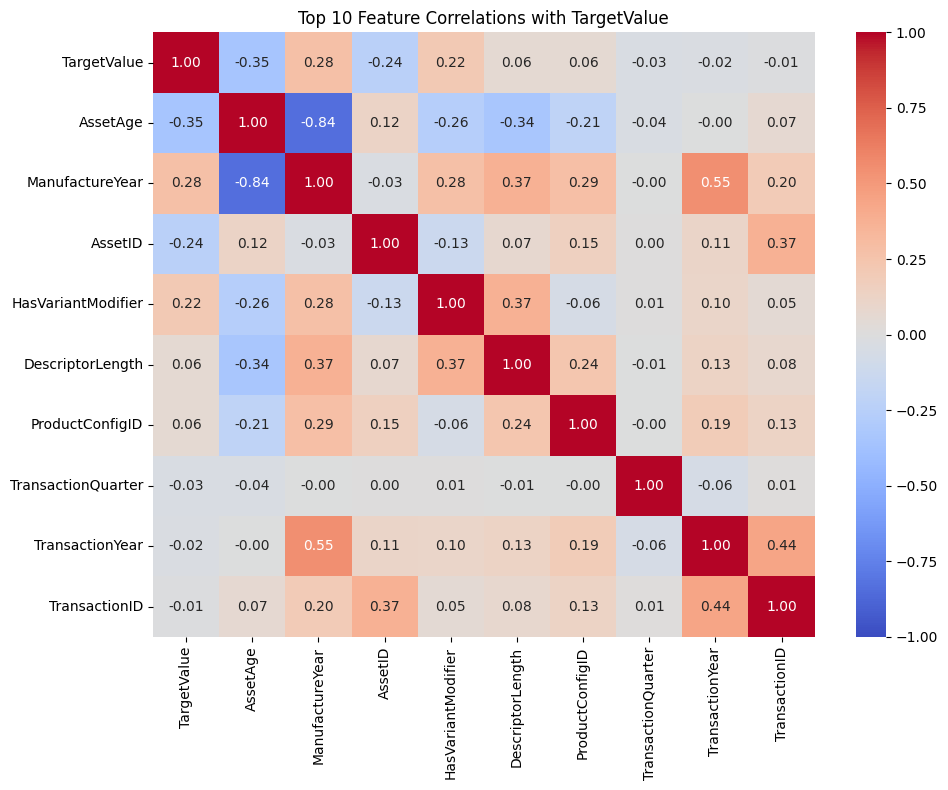

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = train_processed.corr(numeric_only=True)
target_correlation = correlation_matrix['TargetValue'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))

top_features = correlation_matrix.abs().nlargest(10, 'TargetValue')['TargetValue'].index
top_corr_matrix = train_processed[top_features].corr(numeric_only=True)
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Top 10 Feature Correlations with TargetValue")
plt.tight_layout()
plt.show()

In [32]:
# %% [code] Cell 33

options = [
    'remainder__ManufactureYear',
    'remainder__OperationalHoursMeter',
    'remainder__AssetID',
    'remainder__ProductConfigID'
]

columns_to_test = options + ['TargetValue']

specific_corrs = (
    train_df_encoded[columns_to_test]
    .corr()
    .abs()['TargetValue']
    .sort_values(ascending=False)
)

specific_corrs = specific_corrs.drop('TargetValue')

top_option = specific_corrs.index[0]

print(f"The feature from the list with the highest correlation is : {top_option}")

The feature from the list with the highest correlation is : remainder__ManufactureYear


In [33]:
# %% [code] Cell 34

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_cols = [
    "remainder__ManufactureYear",
    "remainder__OperationalHoursMeter",
    "remainder__AssetAge"
]

imputer = SimpleImputer(strategy="mean")
scaler = StandardScaler()

# Training
train_df_encoded[num_cols] = imputer.fit_transform(train_df_encoded[num_cols])
train_df_encoded[num_cols] = scaler.fit_transform(train_df_encoded[num_cols])

# Testing
test_df_encoded[num_cols] = imputer.transform(test_df_encoded[num_cols])
test_df_encoded[num_cols] = scaler.transform(test_df_encoded[num_cols])

In [34]:
# %% [code] Cell 35

from sklearn.model_selection import train_test_split

X = train_df_encoded.drop(columns=["TargetValue"])
y = train_df_encoded["TargetValue"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
print('The shape of the training dataset is ',X_train.shape)

The shape of the training dataset is  (110960, 109)


In [36]:
print('The shape of the validaton dataset is ',X_val.shape)

The shape of the validaton dataset is  (27741, 109)


In [37]:
from sklearn.linear_model import LinearRegression

predictors = ['remainder__ManufactureYear','remainder__AssetAge']

X_train_lr = X_train[predictors]
X_val_lr = X_val[predictors]

lr = LinearRegression()
lr.fit(X_train_lr , y_train)

y_pred = lr.predict(X_val_lr)

In [38]:
from sklearn.metrics import r2_score

r2_scr = r2_score(y_val, y_pred)
print(f"R2 score is : {r2_scr:.4f}")

R2 score is : 0.1132


In [39]:
missing_fraction = train_df.isnull().mean()

columns_to_drop = missing_fraction[missing_fraction > 0.8]

print(f"Exactly {len(columns_to_drop)} columns will be removed.")

Exactly 15 columns will be removed.


In [40]:
median_asset_age = train_processed["AssetAge"].median()

print(median_asset_age)

8.0


In [41]:
train_df["CabinType"] = train_df["CabinType"].fillna("Missing")

missing_cabin_count = (train_df["CabinType"] == "Missing").sum()

print(f"Total rows with 'Missing' in CabinType : {missing_cabin_count}")

Total rows with 'Missing' in CabinType : 0


In [42]:
sale_year_mode = train_processed["TransactionYear"].mode()[0]

print(f"Most frequent SaleYear : {sale_year_mode}")

Most frequent SaleYear : 2010


In [43]:
train_processed["HoursPerYear"] = (
    train_processed["OperationalHoursMeter"] / train_processed["AssetAge"]
)

hours_per_year = train_processed["HoursPerYear"].replace([np.inf, -np.inf], np.nan).dropna()

median_hours = hours_per_year.median()

print(f"Median HoursPerYear : {median_hours:.2f}")

Median HoursPerYear : 320.00


In [44]:
train_processed["LogTargetValue"] = np.log1p(train_processed["TargetValue"])

loged_target_std = train_processed["LogTargetValue"].std()

print(f"Std dev of log1p(TargetValue) : {loged_target_std:.4f}")


Std dev of log1p(TargetValue) : 0.6710


In [45]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

train_processed["UtilizationTier_Encoded"] = encoder.fit_transform(train_processed[["UtilizationTier"]])

unique_int = train_processed["UtilizationTier_Encoded"].nunique()

print(f'Number of unique integers are : {unique_int}')

Number of unique integers are : 3
